In [28]:
import pandas as pd
import yfinance as yf
from ta import add_all_ta_features
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    accuracy_score, roc_auc_score, confusion_matrix, classification_report
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.preprocessing import PolynomialFeatures

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.validation import check_is_fitted

from ta.momentum import (
    RSIIndicator,
    StochasticOscillator,
    StochRSIIndicator,
    WilliamsRIndicator,
    ROCIndicator,
    TSIIndicator,
    UltimateOscillator,
    KAMAIndicator,
    PercentagePriceOscillator,
)

from ta.trend import (
    SMAIndicator,
    EMAIndicator,
    WMAIndicator,
    MACD,
    CCIIndicator,
    ADXIndicator,
    VortexIndicator,
    TRIXIndicator,
    MassIndex,
    DPOIndicator,
    KSTIndicator,
    IchimokuIndicator,
    AroonIndicator,
    PSARIndicator,
    STCIndicator,
)

from ta.volatility import (
    AverageTrueRange,
    BollingerBands,
    KeltnerChannel,
    DonchianChannel,
    UlcerIndex,
)

from ta.others import (
    DailyReturnIndicator,
    DailyLogReturnIndicator,
    CumulativeReturnIndicator,
)

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import (
    make_scorer, 
    balanced_accuracy_score, 
    average_precision_score, 
    matthews_corrcoef, 
    log_loss,
    fbeta_score
)

pd.set_option("display.max_columns", None)

# Загрузка данных

## ohlvc

In [260]:
pairs = {
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "USD/JPY": "JPY=X",
    "USD/CHF": "CHF=X",
    "AUD/USD": "AUDUSD=X",
    "USD/CAD": "CAD=X",
    "NZD/USD": "NZDUSD=X",
    "EUR/GBP": "EURGBP=X",
    "USD/RUB": "RUB=X",
    "EUR/RUB": "EURRUB=X"
}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [265]:
print(*[i[0] for i in pairs.items()], sep=', ')

EUR/USD, GBP/USD, USD/JPY, USD/CHF, AUD/USD, USD/CAD, NZD/USD, EUR/GBP, USD/RUB, EUR/RUB


In [7]:
pairs = {
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "USD/JPY": "JPY=X",
    "USD/CHF": "CHF=X",
    "AUD/USD": "AUDUSD=X",
    "USD/CAD": "CAD=X",
    "NZD/USD": "NZDUSD=X",
    "EUR/GBP": "EURGBP=X",
    "USD/RUB": "RUB=X",
    "EUR/RUB": "EURRUB=X"
}

df = pd.concat([
    yf.download(t, start="2000-01-01", interval="1d", progress=False, auto_adjust=False)
      .droplevel(1, axis=1)
      .reset_index()
      .assign(pair=p)
    for p, t in pairs.items()
], ignore_index=True).sort_values(["pair", "Date"]).reset_index(drop=True)

df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,pair
0,2006-05-16,0.767106,0.767106,0.768994,0.760688,0.762835,0,AUD/USD
1,2006-05-17,0.759417,0.759417,0.772618,0.757576,0.766871,0,AUD/USD
2,2006-05-18,0.764000,0.764000,0.767577,0.758725,0.759417,0,AUD/USD
3,2006-05-19,0.757174,0.757174,0.764818,0.753012,0.763884,0,AUD/USD
4,2006-05-22,0.753409,0.753409,0.756888,0.747105,0.756888,0,AUD/USD


In [8]:
df['pair'] = df['pair'].astype('category')
df.drop(columns=['Adj Close', 'Volume'], inplace=True)
df.columns = ['timestamp', 'close', 'high', 'low', 'open', 'pair']

In [9]:
df

,timestamp,close,high,low,open,pair
0,2006-05-16,0.767106,0.768994,0.760688,0.762835,AUD/USD
1,2006-05-17,0.759417,0.772618,0.757576,0.766871,AUD/USD
2,2006-05-18,0.764000,0.767577,0.758725,0.759417,AUD/USD
3,2006-05-19,0.757174,0.764818,0.753012,0.763884,AUD/USD
4,2006-05-22,0.753409,0.756888,0.747105,0.756888,AUD/USD
...,...,...,...,...,...,...
58962,2026-03-30,80.814583,81.877884,80.602394,80.809662,USD/RUB
58963,2026-03-31,81.289001,81.760643,81.231239,81.295036,USD/RUB
58964,2026-04-01,81.296143,81.311203,80.220909,81.302399,USD/RUB
58965,2026-04-02,80.295410,80.503433,80.036049,80.297493,USD/RUB


## market

In [10]:
pair_market_context = {

# EUR/USD
"EUR/USD": [
    "DX-Y.NYB",      # DXY — индекс доллара
    "^VIX",          # VIX — риск/волатильность
    "^MOVE",         # волатильность облигаций
    "^TNX",          # US 10Y доходность
    "^IRX",          # US short rate
    "BZ=F",          # Brent нефть
    "NG=F",          # газ (proxy)
    "^GSPC",         # S&P 500
    "^STOXX50E",     # Euro Stoxx 50
    "EURCHF=X",      # EUR/CHF (стресс Европы)
    "LQD",           # IG bonds
    "HYG"            # HY bonds
],


# GBP/USD
"GBP/USD": [
    "^TNX",          # US 10Y
    "^IRX",          # US short rate
    "^FTSE",         # FTSE 100
    "^GSPC",         # S&P 500
    "EURGBP=X",      # EUR/GBP
    "DX-Y.NYB",      # DXY
    "^VIX",          # риск
    "HYG",           # credit risk
    "LQD",           # credit IG
    "^STOXX50E"      # Европа
],


# USD/JPY
"USD/JPY": [
    "^TNX",          # US 10Y
    "^IRX",          # US short rate
    "^VIX",          # риск
    "^GSPC",         # акции
    "DX-Y.NYB",      # доллар
    "BZ=F",          # нефть
    "^N225",         # Nikkei
    "GC=F"           # золото
],


# USD/CHF
"USD/CHF": [
    "^TNX",          # US 10Y
    "GC=F",          # золото (safe haven)
    "EURCHF=X",      # Европа стресс
    "SX7E.Z",         # банки Европы
    "^VIX",          # риск
    "^GSPC",         # акции
    "DX-Y.NYB",      # доллар
    "HYG",           # credit risk
    "LQD"            # IG bonds
],


# AUD/USD
"AUD/USD": [
    "HG=F",          # медь
    "GC=F",          # золото
    "BZ=F",          # нефть
    "CL=F",          # нефть WTI
    "000300.SS",     # China CSI 300
    "000001.SS",     # Shanghai
    "^TNX",          # US 10Y
    "^GSPC",         # S&P 500
    "^VIX",          # риск
    "NZDUSD=X",      # NZD/USD
    "AUDNZD=X",      # AUD/NZD
    "DBC"            # commodities ETF
],


# NZD/USD
"NZD/USD": [
    "GC=F",          # золото
    "BZ=F",          # нефть
    "000300.SS",     # China
    "000001.SS",     # China
    "^TNX",          # US 10Y
    "^GSPC",         # акции
    "^VIX",          # риск
    "AUDUSD=X",      # AUD/USD
    "AUDNZD=X",      # cross
    "DBC"            # commodities
],


# USD/CAD
"USD/CAD": [
    "CL=F",          # WTI нефть
    "BZ=F",          # Brent
    "NG=F",          # газ
    "^TNX",          # US 10Y
    "^GSPC",         # S&P 500
    "^GSPTSE",       # TSX
    "^VIX",          # риск
    "DX-Y.NYB",      # доллар
    "GC=F"           # золото
],


# EUR/GBP
"EUR/GBP": [
    "EURUSD=X",      # EUR/USD
    "GBPUSD=X",      # GBP/USD
    "^STOXX50E",     # Европа
    "^FTSE",         # UK
    "BZ=F",          # нефть
    "NG=F",          # газ
    "^VIX"           # риск
],


# USD/RUB
"USD/RUB": [
    "BZ=F",          # Brent (главное)
    "CL=F",          # WTI
    "NG=F",          # газ (proxy)
    "CNY=X",         # USD/CNY (ключ)
    "EURUSD=X",      # глобальный FX
    "DX-Y.NYB",      # доллар
    "^VIX",          # риск
    "^GSPC",         # акции
    "GC=F",          # золото
    "000001.SS"      # Китай
],


# EUR/RUB
"EUR/RUB": [
    "EURUSD=X",      # EUR/USD
    "RUB=X",         # USD/RUB
    "BZ=F",          # нефть
    "CL=F",          # нефть
    "NG=F",          # газ
    "^STOXX50E",     # Европа
    "SX7E.Z",         # банки ЕС
    "CNY=X",         # Китай
    "^VIX",          # риск
    "GC=F"           # золото
]
}

In [11]:
market_features0 = list(set(val for sublist in pair_market_context.values() for val in sublist))
# Уберу признаки которые уже есть в ohlvc
market_features1 = [i for i in market_features0 if not i.endswith('=X')]
df_market = pd.concat([
    yf.download(t, start="2000-01-01", interval="1d", progress=False, auto_adjust=False)
      .droplevel(1, axis=1)
      .reset_index()
      .assign(ticker=t)
    for t in market_features1
], ignore_index=True)
df_market = df_market.rename(columns={'Date': 'timestamp',
                                     'Adj Close': 'close',
                                     'High': 'high',
                                     'Low': 'low',
                                     'Open': 'open',
                                     'Volume': 'volume'})
df_market['timestamp'] = pd.to_datetime(df_market['timestamp'])
df_market.sort_values(['ticker', 'timestamp'], inplace=True)
df_market.reset_index(drop=True, inplace=True)
df_market.index.name = None
df_market.drop(columns='Close', inplace=True)

# Baseline только на ohlvc данных

## EDA

In [221]:
# Фильтрации

In [222]:
pair = 'EUR/USD'
df_pair = df[df['pair'] == pair].iloc[:, :-1].copy()
mk_tk = pair_market_context.get(pair, [])
mk_tk = [i for i in mk_tk if not i.endswith('=X')]

In [223]:
pair_mk = df_market[df_market['ticker'].isin(mk_tk)].copy()
pair_mk = pair_mk.pivot(index="timestamp", columns="ticker")
pair_mk.columns = [f"{col}_{ticker}" for col, ticker in pair_mk.columns]
pair_mk = pair_mk.sort_index()
pair_mk = pair_mk.loc[:, pair_mk.std() != 0].copy() # Уберу колонки без дисперсии
pair_mk = pair_mk.loc[df_pair.timestamp.min():].copy()
pair_mk = pair_mk.loc[:, pair_mk.isna().mean() <= 0.2] # Убрал колонки с более чем 20% пропусков в начале
first_val_index = pair_mk.dropna().index.min() # Первый индекс с которого во всех колонках есть значения
pair_mk_nona = pair_mk.loc[first_val_index:].iloc[:-1].copy() # Уберу строки с явными пропускаии
pair_mk_nona = pair_mk_nona.ffill()

In [224]:
# Генерация фичей

In [225]:
def make_ta_features_grid(
    df: pd.DataFrame,
    fillna: bool = False,
    drop_ohlc: bool = False,
    windows=range(2, 51),
    windows_fast=(5, 8, 12),
    windows_slow=(20, 26, 35),
    windows_sign=(5, 9, 12),
    bb_devs=(1, 2, 3),
    kc_mults=(1, 2, 3),
    psar_steps=(0.02, 0.04, 0.08),
    psar_max_steps=(0.2, 0.4),
    uo_windows=((7, 14, 28), (5, 10, 20), (10, 20, 40)),
    stc_fast=(10, 23),
    stc_slow=(30, 50),
    stc_cycle=(10, 20),
    ichimoku_windows=((9, 26, 52), (7, 22, 44), (12, 24, 48)),
):
    required = {"open", "high", "low", "close"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"В df не хватает колонок: {sorted(missing)}")

    out = df.copy()
    for c in ["open", "high", "low", "close"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    close = out["close"]
    high = out["high"]
    low = out["low"]

    feats = {}

    # others
    feats["dr"] = DailyReturnIndicator(close=close, fillna=fillna).daily_return()
    feats["dlr"] = DailyLogReturnIndicator(close=close, fillna=fillna).daily_log_return()
    feats["cr"] = CumulativeReturnIndicator(close=close, fillna=fillna).cumulative_return()

    # single-window indicators
    for w in windows:
        # trend
        feats[f"sma_{w}"] = SMAIndicator(close=close, window=w, fillna=fillna).sma_indicator()
        feats[f"ema_{w}"] = EMAIndicator(close=close, window=w, fillna=fillna).ema_indicator()
        feats[f"wma_{w}"] = WMAIndicator(close=close, window=w, fillna=fillna).wma()
        feats[f"trix_{w}"] = TRIXIndicator(close=close, window=w, fillna=fillna).trix()
        feats[f"dpo_{w}"] = DPOIndicator(close=close, window=w, fillna=fillna).dpo()
        feats[f"cci_{w}"] = CCIIndicator(high=high, low=low, close=close, window=w, fillna=fillna).cci()

        adx = ADXIndicator(high=high, low=low, close=close, window=w, fillna=fillna)
        feats[f"adx_{w}"] = adx.adx()
        feats[f"adx_pos_{w}"] = adx.adx_pos()
        feats[f"adx_neg_{w}"] = adx.adx_neg()

        vortex = VortexIndicator(high=high, low=low, close=close, window=w, fillna=fillna)
        feats[f"vortex_pos_{w}"] = vortex.vortex_indicator_pos()
        feats[f"vortex_neg_{w}"] = vortex.vortex_indicator_neg()
        feats[f"vortex_diff_{w}"] = vortex.vortex_indicator_diff()

        aroon = AroonIndicator(high=high, low=low, window=w, fillna=fillna)
        feats[f"aroon_up_{w}"] = aroon.aroon_up()
        feats[f"aroon_down_{w}"] = aroon.aroon_down()
        feats[f"aroon_ind_{w}"] = aroon.aroon_indicator()

        # momentum
        feats[f"rsi_{w}"] = RSIIndicator(close=close, window=w, fillna=fillna).rsi()
        feats[f"roc_{w}"] = ROCIndicator(close=close, window=w, fillna=fillna).roc()
        feats[f"tsi_{w}"] = TSIIndicator(
            close=close, window_slow=max(w, 2 * w), window_fast=w, fillna=fillna
        ).tsi()
        feats[f"kama_{w}"] = KAMAIndicator(close=close, window=w, fillna=fillna).kama()
        feats[f"wr_{w}"] = WilliamsRIndicator(
            high=high, low=low, close=close, lbp=w, fillna=fillna
        ).williams_r()

        stoch = StochasticOscillator(
            high=high,
            low=low,
            close=close,
            window=w,
            smooth_window=max(2, min(10, w)),
            fillna=fillna,
        )
        feats[f"stoch_k_{w}"] = stoch.stoch()
        feats[f"stoch_d_{w}"] = stoch.stoch_signal()

        stochrsi = StochRSIIndicator(
            close=close,
            window=w,
            smooth1=max(2, min(10, w)),
            smooth2=max(2, min(10, w)),
            fillna=fillna,
        )
        feats[f"stochrsi_{w}"] = stochrsi.stochrsi()
        feats[f"stochrsi_k_{w}"] = stochrsi.stochrsi_k()
        feats[f"stochrsi_d_{w}"] = stochrsi.stochrsi_d()

        # volatility
        feats[f"atr_{w}"] = AverageTrueRange(
            high=high, low=low, close=close, window=w, fillna=fillna
        ).average_true_range()
        feats[f"ui_{w}"] = UlcerIndex(close=close, window=w, fillna=fillna).ulcer_index()

        dc = DonchianChannel(high=high, low=low, close=close, window=w, offset=0, fillna=fillna)
        feats[f"dc_h_{w}"] = dc.donchian_channel_hband()
        feats[f"dc_l_{w}"] = dc.donchian_channel_lband()
        feats[f"dc_m_{w}"] = dc.donchian_channel_mband()
        feats[f"dc_w_{w}"] = dc.donchian_channel_wband()
        feats[f"dc_p_{w}"] = dc.donchian_channel_pband()

    # Bollinger
    for w in windows:
        for dev in bb_devs:
            bb = BollingerBands(close=close, window=w, window_dev=dev, fillna=fillna)
            suf = f"{w}_{dev}"
            feats[f"bb_h_{suf}"] = bb.bollinger_hband()
            feats[f"bb_l_{suf}"] = bb.bollinger_lband()
            feats[f"bb_m_{suf}"] = bb.bollinger_mavg()
            feats[f"bb_w_{suf}"] = bb.bollinger_wband()
            feats[f"bb_p_{suf}"] = bb.bollinger_pband()
            feats[f"bb_hi_{suf}"] = bb.bollinger_hband_indicator()
            feats[f"bb_li_{suf}"] = bb.bollinger_lband_indicator()

    # Keltner
    for w in windows:
        for mult in kc_mults:
            kc = KeltnerChannel(
                high=high,
                low=low,
                close=close,
                window=w,
                window_atr=w,
                multiplier=mult,
                original_version=True,
                fillna=fillna,
            )
            suf = f"{w}_{mult}"
            feats[f"kc_h_{suf}"] = kc.keltner_channel_hband()
            feats[f"kc_l_{suf}"] = kc.keltner_channel_lband()
            feats[f"kc_m_{suf}"] = kc.keltner_channel_mband()
            feats[f"kc_w_{suf}"] = kc.keltner_channel_wband()
            feats[f"kc_p_{suf}"] = kc.keltner_channel_pband()
            feats[f"kc_hi_{suf}"] = kc.keltner_channel_hband_indicator()
            feats[f"kc_li_{suf}"] = kc.keltner_channel_lband_indicator()

    # MACD / PPO
    for fast in windows_fast:
        for slow in windows_slow:
            if fast >= slow:
                continue
            for sign in windows_sign:
                suf = f"{fast}_{slow}_{sign}"

                macd = MACD(
                    close=close,
                    window_fast=fast,
                    window_slow=slow,
                    window_sign=sign,
                    fillna=fillna,
                )
                feats[f"macd_{suf}"] = macd.macd()
                feats[f"macd_signal_{suf}"] = macd.macd_signal()
                feats[f"macd_diff_{suf}"] = macd.macd_diff()

                ppo = PercentagePriceOscillator(
                    close=close,
                    window_slow=slow,
                    window_fast=fast,
                    window_sign=sign,
                    fillna=fillna,
                )
                feats[f"ppo_{suf}"] = ppo.ppo()
                feats[f"ppo_signal_{suf}"] = ppo.ppo_signal()
                feats[f"ppo_hist_{suf}"] = ppo.ppo_hist()

    # Ultimate Oscillator
    for w1, w2, w3 in uo_windows:
        if w1 < w2 < w3:
            feats[f"uo_{w1}_{w2}_{w3}"] = UltimateOscillator(
                high=high,
                low=low,
                close=close,
                window1=w1,
                window2=w2,
                window3=w3,
                fillna=fillna,
            ).ultimate_oscillator()

    # KST
    kst_cfgs = [
        (10, 15, 20, 30, 10, 10, 10, 15, 9),
        (6, 12, 18, 24, 6, 6, 6, 9, 6),
        (9, 13, 18, 24, 9, 9, 9, 9, 6),
    ]
    for r1, r2, r3, r4, n1, n2, n3, n4, nsig in kst_cfgs:
        suf = f"{r1}_{r2}_{r3}_{r4}_{n1}_{n2}_{n3}_{n4}_{nsig}"
        kst = KSTIndicator(
            close=close,
            roc1=r1,
            roc2=r2,
            roc3=r3,
            roc4=r4,
            window1=n1,
            window2=n2,
            window3=n3,
            window4=n4,
            nsig=nsig,
            fillna=fillna,
        )
        feats[f"kst_{suf}"] = kst.kst()
        feats[f"kst_sig_{suf}"] = kst.kst_sig()
        feats[f"kst_diff_{suf}"] = kst.kst_diff()

    # Ichimoku
    for w1, w2, w3 in ichimoku_windows:
        if w1 < w2 < w3:
            ichi = IchimokuIndicator(
                high=high, low=low, window1=w1, window2=w2, window3=w3, fillna=fillna
            )
            suf = f"{w1}_{w2}_{w3}"
            feats[f"ichi_conv_{suf}"] = ichi.ichimoku_conversion_line()
            feats[f"ichi_base_{suf}"] = ichi.ichimoku_base_line()
            feats[f"ichi_a_{suf}"] = ichi.ichimoku_a()
            feats[f"ichi_b_{suf}"] = ichi.ichimoku_b()

    # PSAR
    for step in psar_steps:
        for max_step in psar_max_steps:
            if step >= max_step:
                continue
            psar = PSARIndicator(
                high=high, low=low, close=close, step=step, max_step=max_step, fillna=fillna
            )
            suf = f"{str(step).replace('.', 'p')}_{str(max_step).replace('.', 'p')}"
            feats[f"psar_{suf}"] = psar.psar()
            feats[f"psar_up_{suf}"] = psar.psar_up()
            feats[f"psar_down_{suf}"] = psar.psar_down()
            feats[f"psar_up_ind_{suf}"] = psar.psar_up_indicator()
            feats[f"psar_down_ind_{suf}"] = psar.psar_down_indicator()

    # STC
    for fast in stc_fast:
        for slow in stc_slow:
            if fast >= slow:
                continue
            for cycle in stc_cycle:
                feats[f"stc_{fast}_{slow}_{cycle}"] = STCIndicator(
                    close=close,
                    window_slow=slow,
                    window_fast=fast,
                    cycle=cycle,
                    smooth1=3,
                    smooth2=3,
                    fillna=fillna,
                ).stc()

    # Mass Index
    for fast, slow in ((9, 25), (5, 20), (10, 30)):
        if fast < slow:
            feats[f"mass_{fast}_{slow}"] = MassIndex(
                high=high, low=low, window_fast=fast, window_slow=slow, fillna=fillna
            ).mass_index()

    feat_df = pd.DataFrame(feats, index=out.index)
    feat_df = feat_df.replace([np.inf, -np.inf], np.nan)

    if drop_ohlc:
        out = out.drop(columns=["open", "high", "low", "close"], errors="ignore")

    return pd.concat([out, feat_df], axis=1)

In [226]:
df_pair_features = make_ta_features_grid(df_pair).copy()

In [227]:
df_pair_features.shape

(5796, 3861)

In [228]:
# Фильтрация 1 этапа и обработка пропусков
df_pair_features.set_index('timestamp', inplace=True)
df_pair_features = df_pair_features.loc[:, df_pair_features.isna().mean() < 0.01].copy()
df_pair_features = df_pair_features.loc[:, df_pair_features.std() != 0].copy()
df_pair_features = df_pair_features.loc[df_pair_features.dropna().index.min():].ffill().copy()

In [229]:
# Ушли около 200 колонок и 50 первых строк (из за наибольшего window) - что допустимо
df_pair_features.shape

(5739, 3672)

In [230]:
df_pair_features['target'] = (df_pair_features['close'] / df_pair_features['open'] - 1).shift(-1)
df_pair_features.dropna(inplace=True)

In [231]:
# Возьму для отбора половину данных на тест
train = df_pair_features.iloc[:len(df_pair_features) // 2].copy()
test = df_pair_features.iloc[len(df_pair_features) // 2:].copy()

In [232]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.7, max_features=15):
        """
        threshold: float, порог корреляции между признаками (мультиколлинеарность)
        max_features: int, сколько лучших признаков оставить в итоге
        """
        self.threshold = threshold
        self.max_features = max_features

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        y = pd.Series(y, index=X.index, name="target")
        
        # Работаем только с числовыми признаками
        X_num = X.select_dtypes(include=[np.number])
        
        # 1. Считаем корреляцию с таргетом и сразу СОРТИРУЕМ по убыванию
        target_corr = X_num.corrwith(y).abs().sort_values(ascending=False)
        
        # 2. Матрица корреляций между всеми числовыми признаками
        corr_matrix = X_num.corr().abs()
        
        selected_features = []
        dropped_features = []
        
        # 3. Улучшенный жадный отбор
        for feature in target_corr.index:
            # Если мы уже набрали нужное количество признаков (топ-K), 
            # все остальные автоматически идут на удаление
            if len(selected_features) >= self.max_features:
                dropped_features.append(feature)
                continue
                
            # Проверяем, коррелирует ли текущий признак с теми, что мы УЖЕ отобрали.
            # Поскольку мы идем по убыванию силы признаков, в selected_features 
            # всегда лежат признаки, которые сильнее текущего.
            is_collinear = False
            for kept_feature in selected_features:
                if corr_matrix.loc[feature, kept_feature] > self.threshold:
                    is_collinear = True
                    break
                    
            # Если признак дублирует информацию уже отобранного сильного признака — удаляем
            if is_collinear:
                dropped_features.append(feature)
            else:
                selected_features.append(feature)
                
        # 4. Сохраняем нечисловые колонки (если они есть), так как мы их не анализировали
        non_numeric_cols = [c for c in X.columns if c not in X_num.columns]
        
        self.features_to_keep_ = selected_features + non_numeric_cols
        self.features_to_drop_ = [c for c in X.columns if c not in self.features_to_keep_]
        
        return self
    
    def transform(self, X):
        check_is_fitted(self, 'features_to_keep_')
        
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        return X.drop(columns=self.features_to_drop_, errors='ignore')
    
    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, 'features_to_keep_')
        return np.array(self.features_to_keep_)

In [233]:
X_train, y_train = train.drop(columns='target'), train['target']
X_test, y_test = test.drop(columns='target'), test['target']

In [234]:
# Обычный корреляционный фильтр потому что baseline - линейный logreg
corr_filter = CorrelationFilter(threshold=0.7, max_features=15)
corr_filter.fit(X_train, y_train)
X_train_transformed = corr_filter.transform(X_train)

In [235]:
X_test_transformed = corr_filter.transform(X_test)

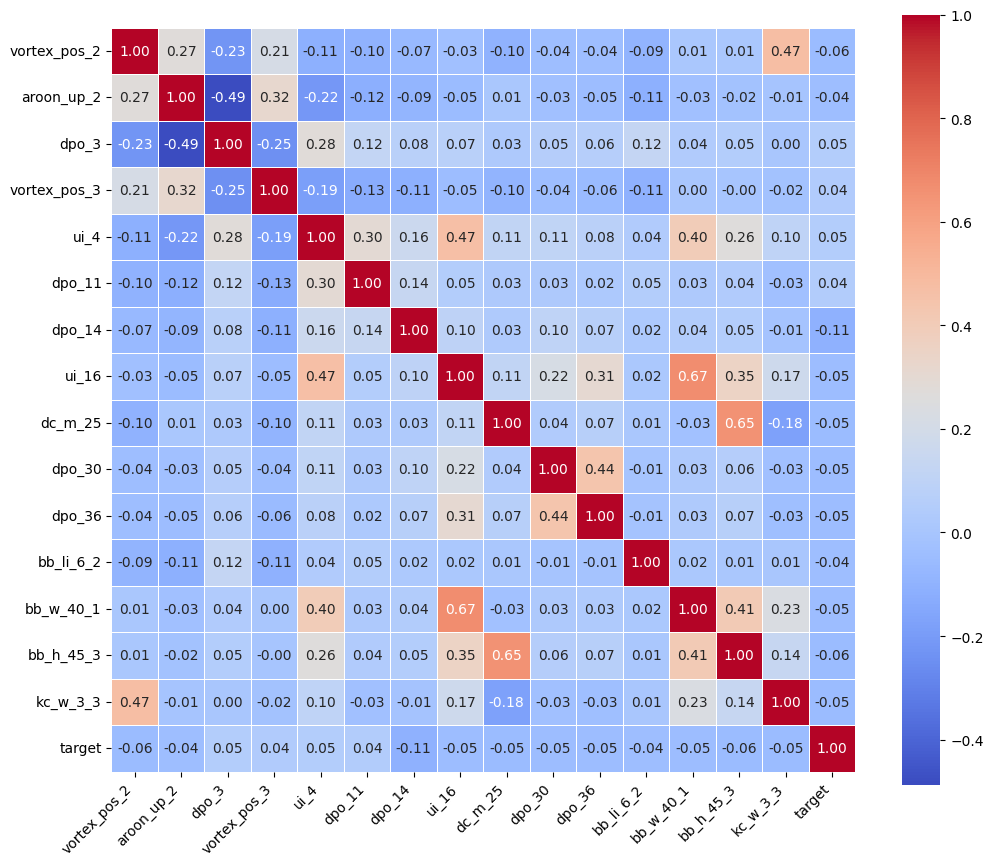

In [236]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Корреляции с таргетом на трейне средние - если учитывать что это return**

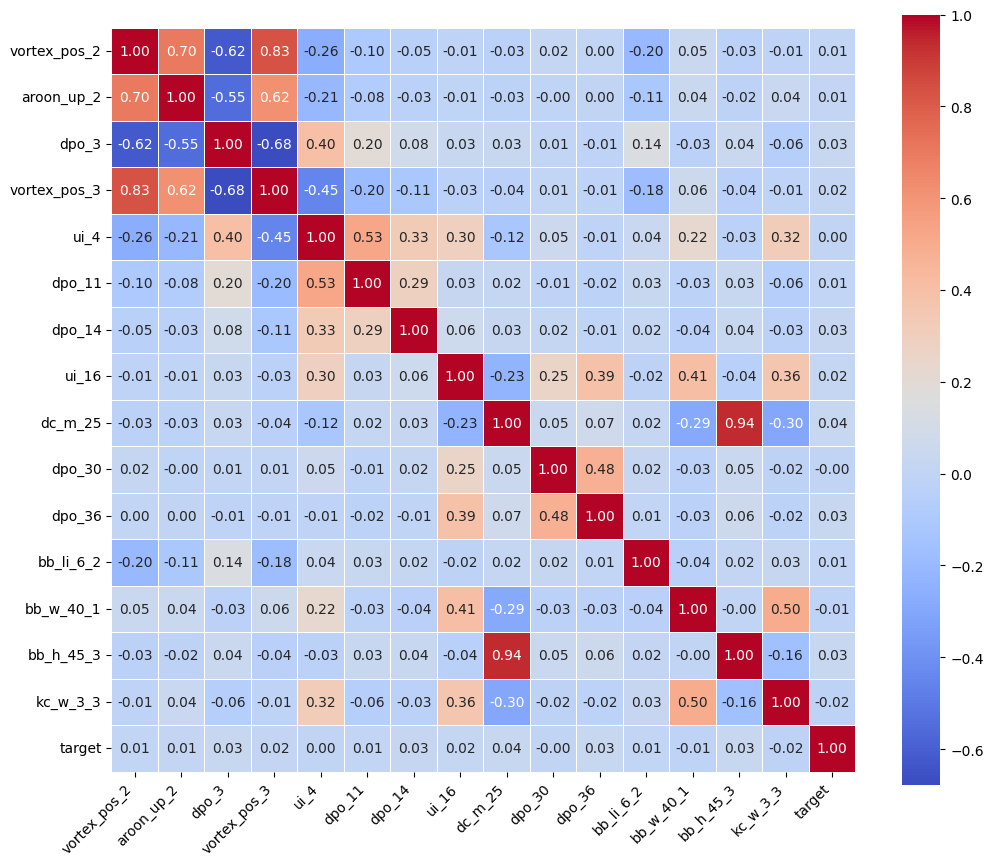

In [237]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_test_transformed, y_test], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [238]:
poly = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly.fit_transform(X_train_transformed)
X_test_poly = poly.transform(X_test_transformed)
feature_names = poly.get_feature_names_out(X_train_transformed.columns)
X_train_poly = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train_transformed.index)
X_test_poly  = pd.DataFrame(X_test_poly,  columns=feature_names, index=X_test_transformed.index)

# Обычный корреляционный фильтр потому что baseline - линейный logreg
corr_filter = CorrelationFilter(threshold=0.7, max_features=15)
corr_filter.fit(X_train_poly, y_train)
X_train_poly_transformed = corr_filter.transform(X_train_poly)
X_test_poly_transformed = corr_filter.transform(X_test_poly)

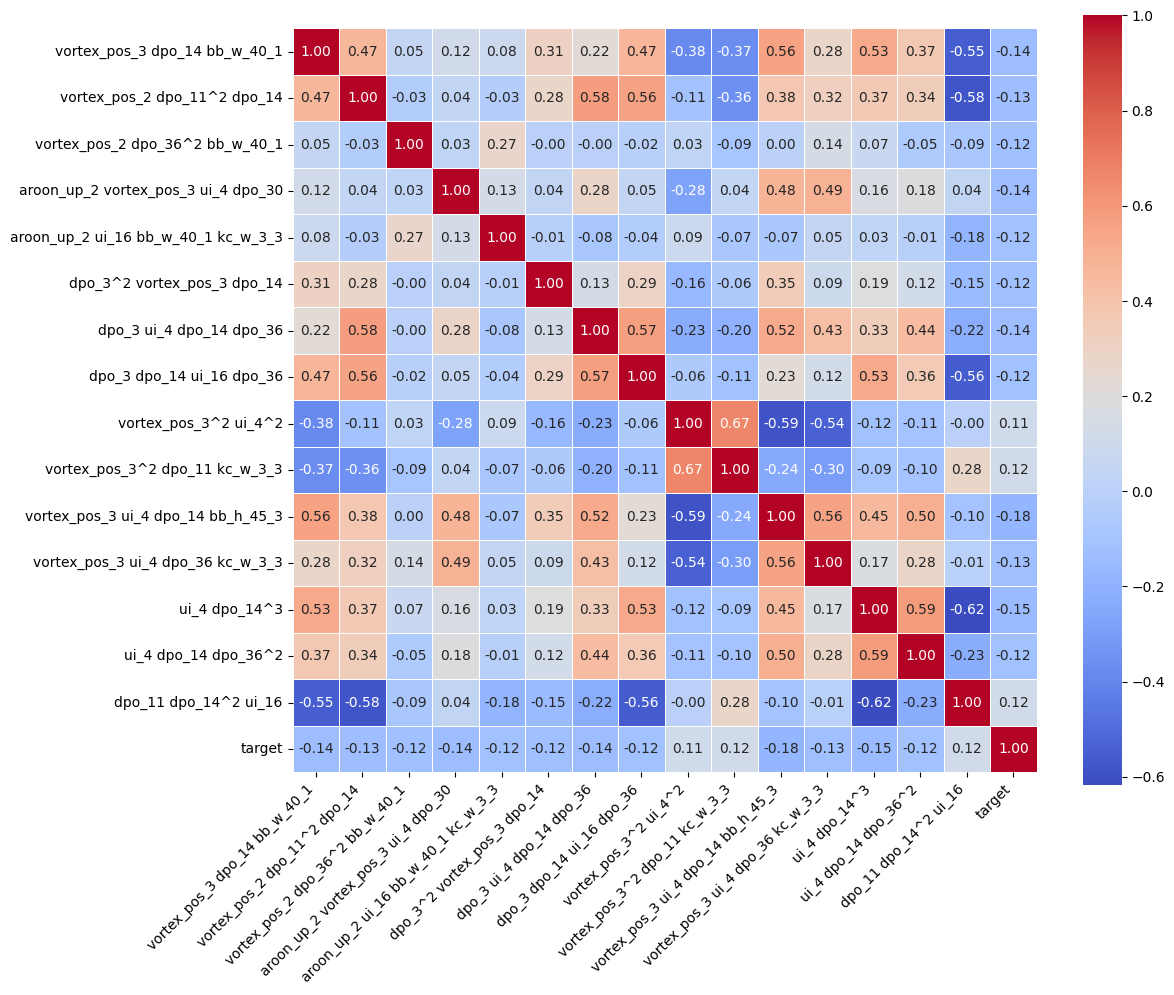

In [239]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_poly_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Видим корреляции сильно увеличились на трейне**

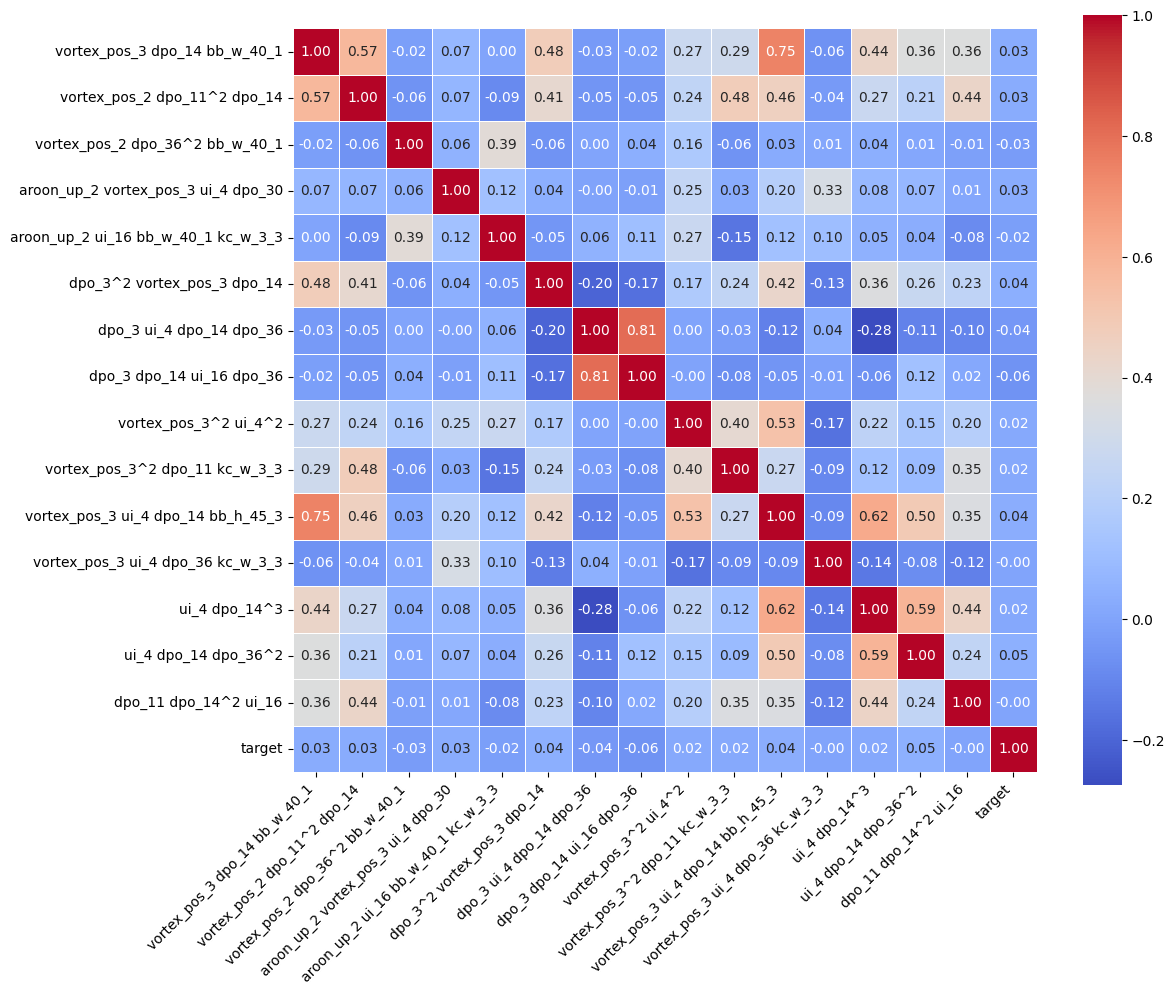

In [240]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_test_poly_transformed, y_test], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**На тесте тоже растет - значит не бесполезным делом занимаемся**

In [241]:
pd.concat([X_test_transformed, y_test], axis=1).corr()['target'].abs().iloc[:-1].mean()

0.01809565476865897

In [242]:
pd.concat([X_test_poly_transformed, y_test], axis=1).corr()['target'].abs().iloc[:-1].mean()

0.0283856303429598

## Baseline на ohlvc

In [253]:
# 1. Подготовка бинарных таргетов
y_train_bin = (y_train >= 0).astype(int)
y_test_bin = (y_test >= 0).astype(int)

# 2. Pipeline
pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet", 
        solver="saga", 
        max_iter=10000, 
        random_state=42,
        class_weight="balanced"  # Оставляем для борьбы с дисбалансом
    ))
])

# 3. Сетка параметров
# Добавил C=0.001 для еще более сильной регуляризации, если нужно
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.1, 0.5, 0.9]
}

# 4. Поиск по сетке (ВАЖНО: меняем на roc_auc)
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1", # Чтобы модель училась различать классы, а не подстраиваться под объем
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train_poly_transformed, y_train_bin)
best_model = grid.best_estimator_

# 5. Прогноз вероятностей
y_proba = best_model.predict_proba(X_test_poly_transformed)[:, 1]

# 6. РУЧНОЙ ПОРОГ (Threshold) - беру y_test_bin.mean() чтобы подгонялась доля классов как в тесте
y_pred = (y_proba >= 0.5).astype(int)

# 7. Расчет метрик по новому порогу
f1 = f1_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
accuracy = accuracy_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_proba) # AUC считаем по вероятностям!
tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred).ravel()

In [254]:
grid.best_params_

{'clf__C': 0.001, 'clf__l1_ratio': 0.5}

In [255]:
grid.best_score_

0.5895327600900984

In [256]:
y_pred.mean()

0.6054374346462182

In [257]:
print(classification_report(y_test_bin, y_pred))

              precision    recall  f1-score   support

           0       0.27      0.40      0.32       769
           1       0.73      0.61      0.66      2100

    accuracy                           0.55      2869
   macro avg       0.50      0.50      0.49      2869
weighted avg       0.61      0.55      0.57      2869



In [258]:
roc_auc

0.489855099386959

In [259]:
print(f"TP: {tp} | FP: {fp}")
print(f"TN: {tn} | FN: {fn}")

TP: 1272 | FP: 465
TN: 304 | FN: 828


**Мои выводы:**

`Модель стала работать чуть честнее, чем раньше, но ситуация по-прежнему критическая. Раньше она просто повторяла за большинством, а теперь пытается хоть что-то предсказывать, но ошибается в обратную сторону. Фактически она чаще дает высокую вероятность проигрыша там, где будет выигрыш, и наоборот. Если бы её прогнозы просто перевернуть, результат был бы чуть лучше, но всё равно очень плохо.`

`По цифрам видно, что модель стала крайне осторожной — она боится предсказывать рост и ошибается в большинстве своих редких предсказаний. При этом она признала почти все ваши признаки бесполезными и оставила всего один-два фактора. Скорее всего, в данных просто нет информации о будущем движении цены, либо зависимости слишком сложные для этой модели, либо рынок на тестовом периоде вёл себя совсем не так, как на обучающем. В любом случае, результат говорит о том, что предсказывать рост или падение на таких данных с этой моделью не получается.`

# Baseline + доп признаки

In [18]:
pair_mk_nona.columns = pd.MultiIndex.from_tuples([col.split("_", 1)[::-1] for col in pair_mk_nona.columns])

In [19]:
fet_full = pd.concat([
    make_ta_features_grid(
        df=pair_mk_nona[symbol].copy(),
        windows=(5, 21),
        windows_fast=(12,),
        windows_slow=(26,),
        windows_sign=(9,),
        bb_devs=(2,),
        kc_mults=(2,),
        psar_steps=(0.02,),
        psar_max_steps=(0.2,),
        uo_windows=((7, 14, 28),),
        stc_fast=(23,),
        stc_slow=(50,),
        stc_cycle=(10,),
        ichimoku_windows=((9, 26, 52),),
    ).pipe(lambda df_: df_.set_axis(
        pd.MultiIndex.from_product([[symbol], df_.columns]),
        axis=1
    ))
    for symbol in pair_mk_nona.columns.get_level_values(0).unique()
], axis=1)

/opt/anaconda3/envs/vse/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/opt/anaconda3/envs/vse/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/opt/anaconda3/envs/vse/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/opt

In [20]:
fet_full.shape

(4809, 1417)

In [21]:
# Фильтрация 1 этапа и обработка пропусков
fet_full = fet_full.loc[:, fet_full.isna().mean() < 0.01].copy()
fet_full = fet_full.loc[:, fet_full.std() != 0].copy()
fet_full = fet_full.loc[fet_full.dropna().index.min():].ffill().copy()

In [22]:
fet_full.shape

(4762, 1312)

In [23]:
df_pair['target'] = (df_pair['close'] / df_pair['open']).shift(-1) - 1
df_pair.dropna()
df_pair.set_index('timestamp', inplace=True)
fet_full[('target', '')] = df_pair['target'].reindex(fet_full.index.get_level_values(-1)).values

In [24]:
fet_full['target']

timestamp
2007-10-03    1.002558
2007-10-04    0.999859
2007-10-05    0.992933
2007-10-08    1.004204
2007-10-09    1.002347
                ...   
2026-03-27    1.000011
2026-03-30    1.000183
2026-03-31    1.000266
2026-04-01    0.999919
2026-04-02    0.998847
Name: target, Length: 4762, dtype: float64

In [25]:
# Возьму для отбора половину данных на тест
train = fet_full.iloc[:len(fet_full) // 2].copy()
test = fet_full.iloc[len(fet_full) // 2:].copy()
X_train, y_train = train.drop(columns='target'), train['target']
X_test, y_test = test.drop(columns='target'), test['target']

In [26]:
# Обычный корреляционный фильтр потому что baseline - линейный logreg
corr_filter = CorrelationFilter(threshold=0.7, max_features=15)
corr_filter.fit(X_train, y_train)
X_train_transformed = corr_filter.transform(X_train)
X_test_transformed = corr_filter.transform(X_test)

/opt/anaconda3/envs/vse/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/vse/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


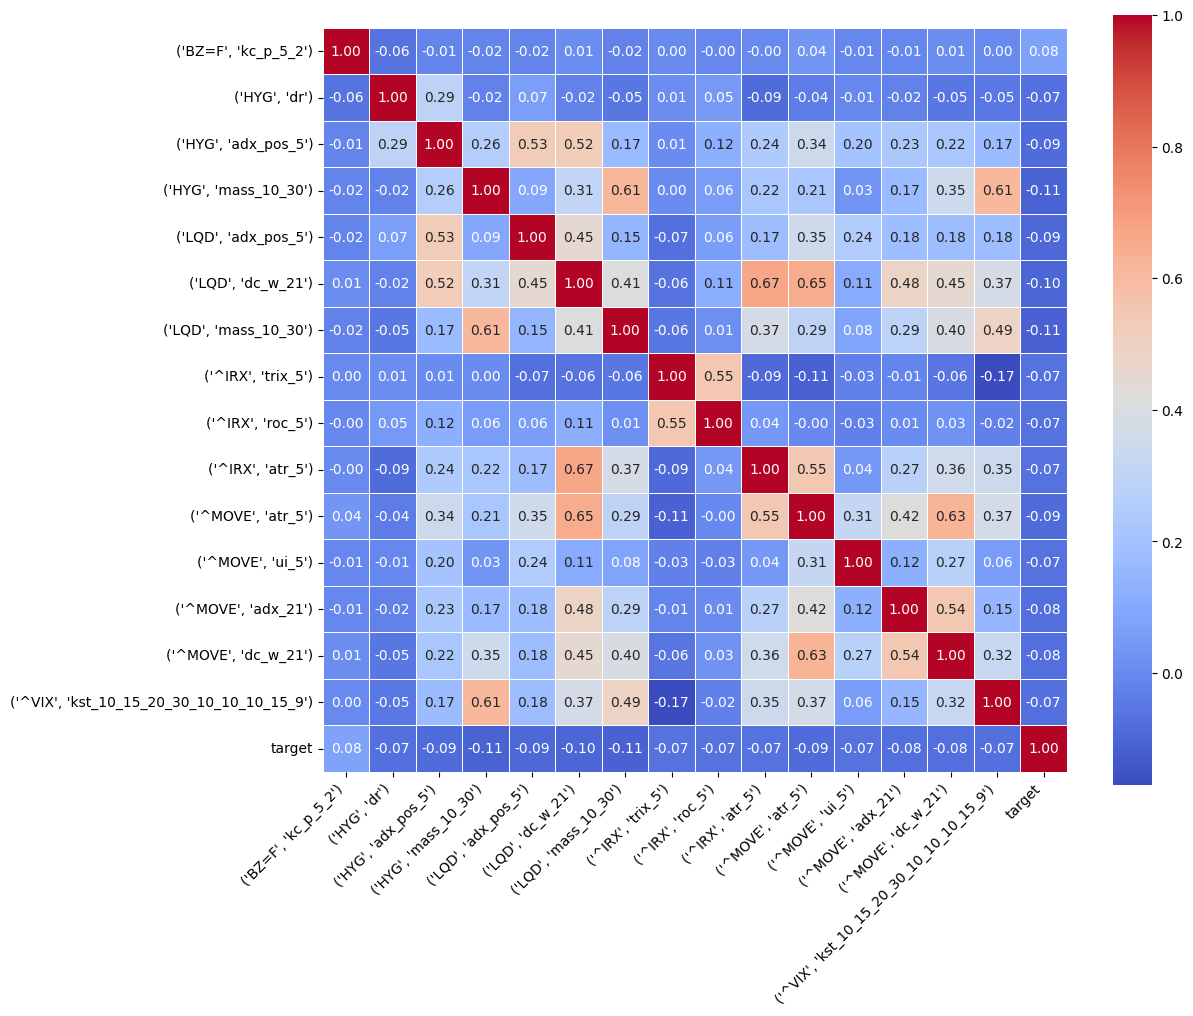

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [33]:
X_train_transformed.columns = ['__'.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in X_train_transformed.columns]
X_test_transformed.columns  = ['__'.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in X_test_transformed.columns]

In [36]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_transformed)
X_test_poly = poly.transform(X_test_transformed)
feature_names = poly.get_feature_names_out(X_train_transformed.columns)
X_train_poly = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train_transformed.index)
X_test_poly  = pd.DataFrame(X_test_poly,  columns=feature_names, index=X_test_transformed.index)

# Обычный корреляционный фильтр потому что baseline - линейный logreg
corr_filter = CorrelationFilter(threshold=0.7, max_features=15)
corr_filter.fit(X_train_poly, y_train)
X_train_poly_transformed = corr_filter.transform(X_train_poly)
X_test_poly_transformed = corr_filter.transform(X_test_poly)

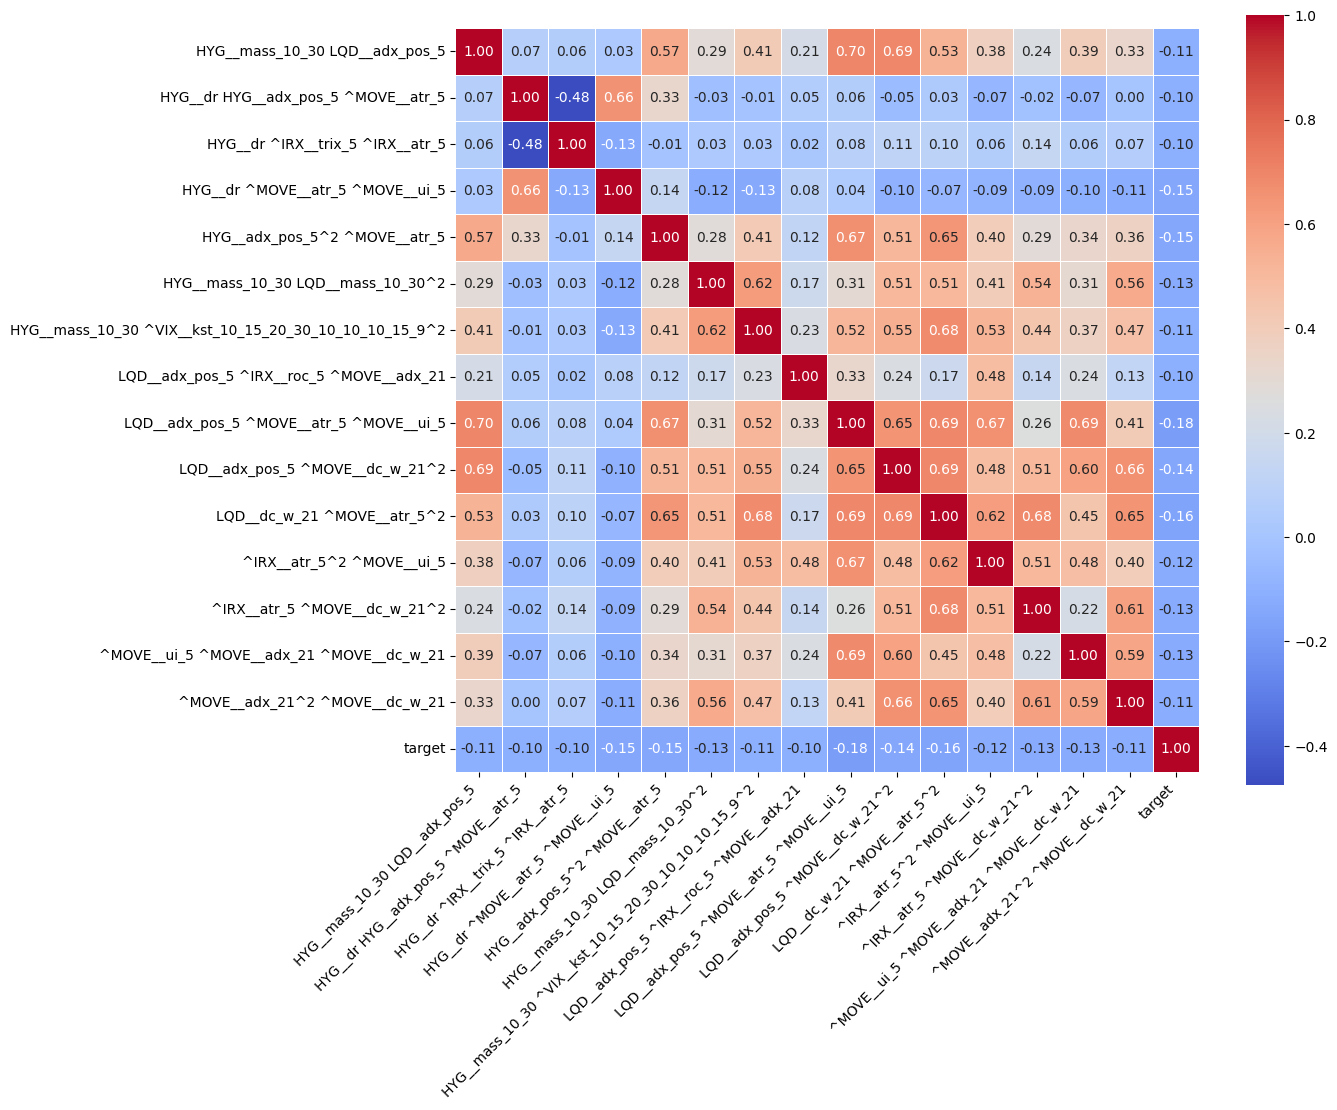

In [37]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_poly_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [43]:
X_train_poly_transformed

,HYG__mass_10_30 LQD__adx_pos_5,HYG__dr HYG__adx_pos_5 ^MOVE__atr_5,HYG__dr ^IRX__trix_5 ^IRX__atr_5,HYG__dr ^MOVE__atr_5 ^MOVE__ui_5,HYG__adx_pos_5^2 ^MOVE__atr_5,HYG__mass_10_30 LQD__mass_10_30^2,HYG__mass_10_30 ^VIX__kst_10_15_20_30_10_10_10_15_9^2,LQD__adx_pos_5 ^IRX__roc_5 ^MOVE__adx_21,LQD__adx_pos_5 ^MOVE__atr_5 ^MOVE__ui_5,LQD__adx_pos_5 ^MOVE__dc_w_21^2,LQD__dc_w_21 ^MOVE__atr_5^2,^IRX__atr_5^2 ^MOVE__ui_5,^IRX__atr_5 ^MOVE__dc_w_21^2,^MOVE__ui_5 ^MOVE__adx_21 ^MOVE__dc_w_21,^MOVE__adx_21^2 ^MOVE__dc_w_21
timestamp,,,,,,,,,,,,,,,
2007-10-03,6.690072,-0.345784,-0.007256,-3.186436,0.169201,26185.988305,1.439061e+06,14.346371,1.305427,89.162254,25.637346,0.034888,49.733747,539.931879,2524.872462
2007-10-04,13.388297,0.181713,0.011315,2.039214,0.088551,26403.553124,1.632543e+06,31.033167,2.084506,180.682504,17.055840,0.026019,43.917297,518.331844,2433.978263
2007-10-05,10.695514,0.025288,0.002128,0.495175,0.078735,26578.842970,1.828963e+06,17.521323,2.984130,197.936228,23.691514,0.038579,59.384203,919.275969,2851.350374
2007-10-08,11.351848,0.165666,0.011295,2.745521,0.124594,26870.268392,2.105240e+06,7.494621,3.024953,214.147450,15.157583,0.030097,48.861575,1104.187133,2879.918785
2007-10-09,9.043620,0.044995,0.002599,1.384605,0.118909,26942.824005,2.259259e+06,5.247406,5.362052,276.391280,33.656605,0.036734,71.395049,2156.676252,3918.452440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-01-03,15.589893,0.240886,-0.007904,2.796196,0.193876,23056.957580,3.583561e+05,-28.798603,3.835133,131.417854,6.592755,0.004021,7.409218,595.453081,1546.840662
2017-01-04,17.100114,0.413414,-0.004310,2.078049,0.403698,22980.868935,3.089668e+05,28.747730,2.408724,94.299575,5.314242,0.003202,5.225269,321.349871,1195.018244
2017-01-05,24.518308,-0.076993,-0.000403,-0.312345,0.227769,23073.548825,2.533831e+05,22.890552,1.893141,102.159230,4.590796,0.001692,3.488373,183.709011,994.844100


In [64]:
y_train

timestamp
2007-10-03    1.002558
2007-10-04    0.999859
2007-10-05    0.992933
2007-10-08    1.004204
2007-10-09    1.002347
                ...   
2017-01-03    1.000146
2017-01-04    1.000210
2017-01-05    1.000032
2017-01-06    0.999789
2017-01-09    1.000095
Name: target, Length: 2381, dtype: float64

In [95]:
# 1. Подготовка бинарных таргетов
y_train_bin = (y_train >= 1).astype(int)
y_test_bin = (y_test >= 1).astype(int)

# 2. Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet", 
        solver="saga", 
        max_iter=10000, 
        random_state=42,
        class_weight="balanced"  # Оставляем для борьбы с дисбалансом
    ))
])

# 3. Сетка параметров
# Добавил C=0.001 для еще более сильной регуляризации, если нужно
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.1, 0.5, 0.9]
}

# 4. Поиск по сетке (ВАЖНО: меняем на roc_auc)
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1", # Чтобы модель училась различать классы, а не подстраиваться под объем
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train_poly_transformed, y_train_bin)
best_model = grid.best_estimator_

# 5. Прогноз вероятностей
y_proba = best_model.predict_proba(X_test_poly_transformed)[:, 1]

# 6. РУЧНОЙ ПОРОГ (Threshold) - беру y_test_bin.mean() чтобы подгонялась доля классов как в тесте
# threshold = np.quantile(y_proba, y_test_bin.mean())
threshold = 0.47
y_pred = (y_proba >= threshold).astype(int)

# 7. Расчет метрик по новому порогу
f1 = f1_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
accuracy = accuracy_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_proba) # AUC считаем по вероятностям!
tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred).ravel()

In [96]:
y_pred.mean()

0.749265014699706

In [97]:
print(classification_report(y_test_bin, y_pred))

              precision    recall  f1-score   support

           0       0.12      0.12      0.12       588
           1       0.71      0.71      0.71      1793

    accuracy                           0.56      2381
   macro avg       0.42      0.42      0.42      2381
weighted avg       0.57      0.56      0.56      2381



In [98]:
roc_auc

0.3461809151993201

In [99]:
print(f"TP: {tp} | FP: {fp}")
print(f"TN: {tn} | FN: {fn}")

TP: 1269 | FP: 515
TN: 73 | FN: 524


**Вывод:**
`Результаты сильно не улучшились - roc/auc показывает значение ниже случайного выпадения`

# Baseline + нелинейный отбор признаков

In [102]:
class MutualInfoFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.7, max_features=15, discrete_features='auto', random_state=42):
        """
        threshold: float, порог корреляции между признаками (для удаления дублей)
        max_features: int, сколько лучших признаков по MI оставить
        discrete_features: 'auto', bool или array, указывает, какие признаки дискретны
        """
        self.threshold = threshold
        self.max_features = max_features
        self.discrete_features = discrete_features
        self.random_state = random_state

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # Работаем только с числовыми признаками
        X_num = X.select_dtypes(include=[np.number])
        
        # 1. Считаем Mutual Information между признаками и таргетом
        # Чем выше MI, тем больше информации признак дает о таргете
        mi_scores = mutual_info_classif(
            X_num, y, 
            discrete_features=self.discrete_features,
            random_state=self.random_state
        )
        
        mi_series = pd.Series(mi_scores, index=X_num.columns).sort_values(ascending=False)
        
        # 2. Матрица корреляций (оставляем её для борьбы с мультиколлинеарностью)
        # Мы хотим лучшие признаки по MI, но чтобы они не были клонами друг друга
        corr_matrix = X_num.corr().abs()
        
        selected_features = []
        
        # 3. Жадный отбор на основе MI
        for feature in mi_series.index:
            if len(selected_features) >= self.max_features:
                break
                
            # Проверяем, не слишком ли сильно текущий признак коррелирует с уже отобранными
            is_redundant = False
            for kept_feature in selected_features:
                if corr_matrix.loc[feature, kept_feature] > self.threshold:
                    is_redundant = True
                    break
            
            if not is_redundant:
                selected_features.append(feature)
        
        # 4. Сохраняем результат
        non_numeric_cols = [c for c in X.columns if c not in X_num.columns]
        self.features_to_keep_ = selected_features + non_numeric_cols
        self.features_to_drop_ = [c for c in X.columns if c not in self.features_to_keep_]
        
        return self

    def transform(self, X):
        check_is_fitted(self, 'features_to_keep_')
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X.drop(columns=self.features_to_drop_, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, 'features_to_keep_')
        return np.array(self.features_to_keep_)

In [105]:
y_train

timestamp
2007-10-03    1.002558
2007-10-04    0.999859
2007-10-05    0.992933
2007-10-08    1.004204
2007-10-09    1.002347
                ...   
2017-01-03    1.000146
2017-01-04    1.000210
2017-01-05    1.000032
2017-01-06    0.999789
2017-01-09    1.000095
Name: target, Length: 2381, dtype: float64

In [107]:
y_train = y_train.ffill()

In [109]:
X_train.shape

(2381, 1312)

In [110]:
y_train.shape

(2381,)

In [112]:
y_train = y_train.ffill() - 1

In [116]:
# Нелинейный mutual info filter
mutual_filter = MutualInfoFilter(threshold=0.7, max_features=15)
mutual_filter.fit(X_train, (y_train >= 0).astype(int))  # Передаю классы 1 - рост / 0 - падение
X_train_transformed = mutual_filter.transform(X_train)
X_test_transformed = mutual_filter.transform(X_test)

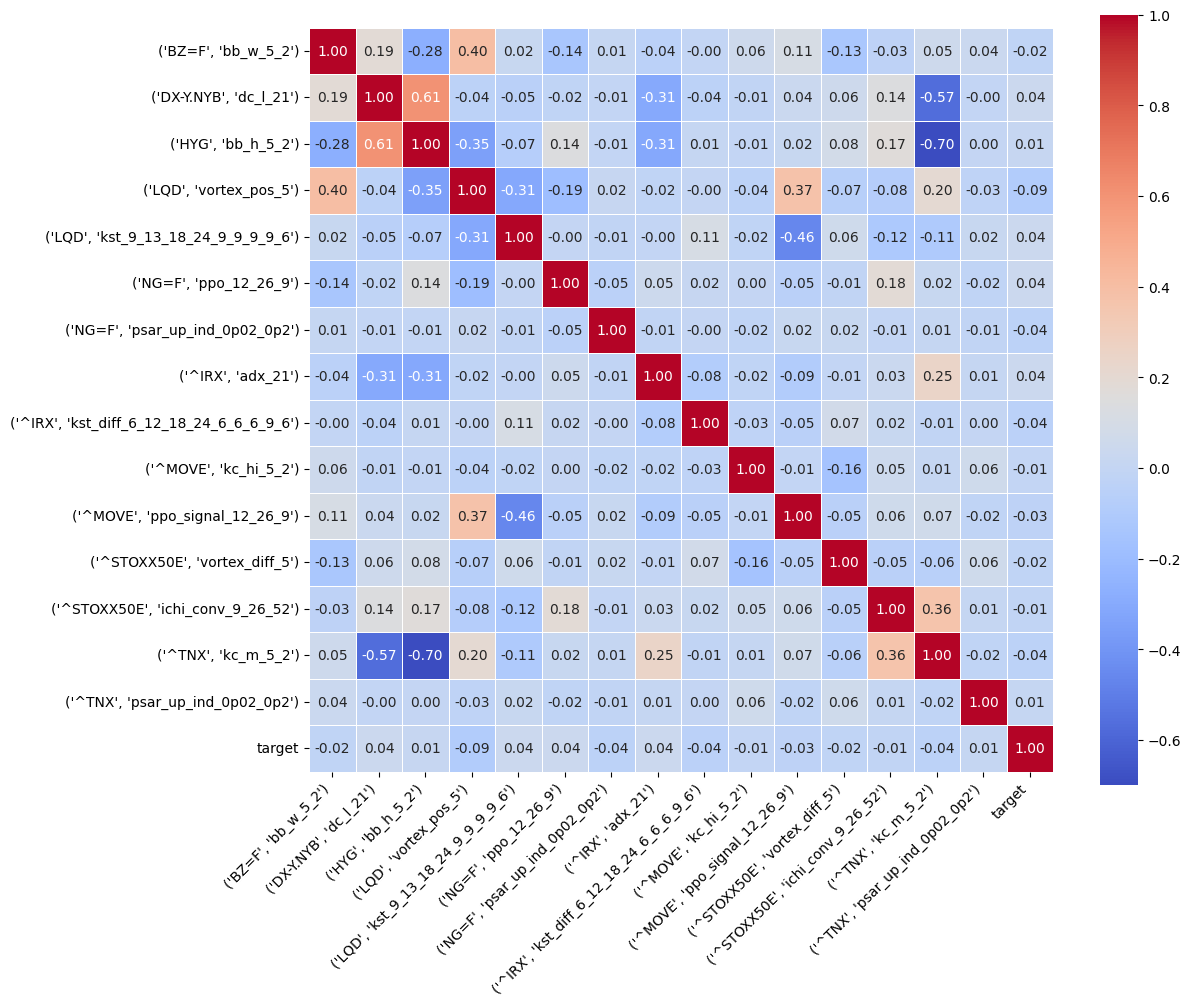

In [119]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

`Корреляции с таргетом низкие, а что если сделать полиномиальные признаки?`

In [122]:
X_train_transformed.columns = ['__'.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in X_train_transformed.columns]
X_test_transformed.columns  = ['__'.join(map(str, c)) if isinstance(c, tuple) else str(c) for c in X_test_transformed.columns]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_transformed)
X_test_poly = poly.transform(X_test_transformed)
feature_names = poly.get_feature_names_out(X_train_transformed.columns)
X_train_poly = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train_transformed.index)
X_test_poly  = pd.DataFrame(X_test_poly,  columns=feature_names, index=X_test_transformed.index)

# Обычный корреляционный фильтр потому что baseline - линейный logreg
corr_filter = CorrelationFilter(threshold=0.7, max_features=15)
corr_filter.fit(X_train_poly, y_train)
X_train_poly_transformed = corr_filter.transform(X_train_poly)
X_test_poly_transformed = corr_filter.transform(X_test_poly)

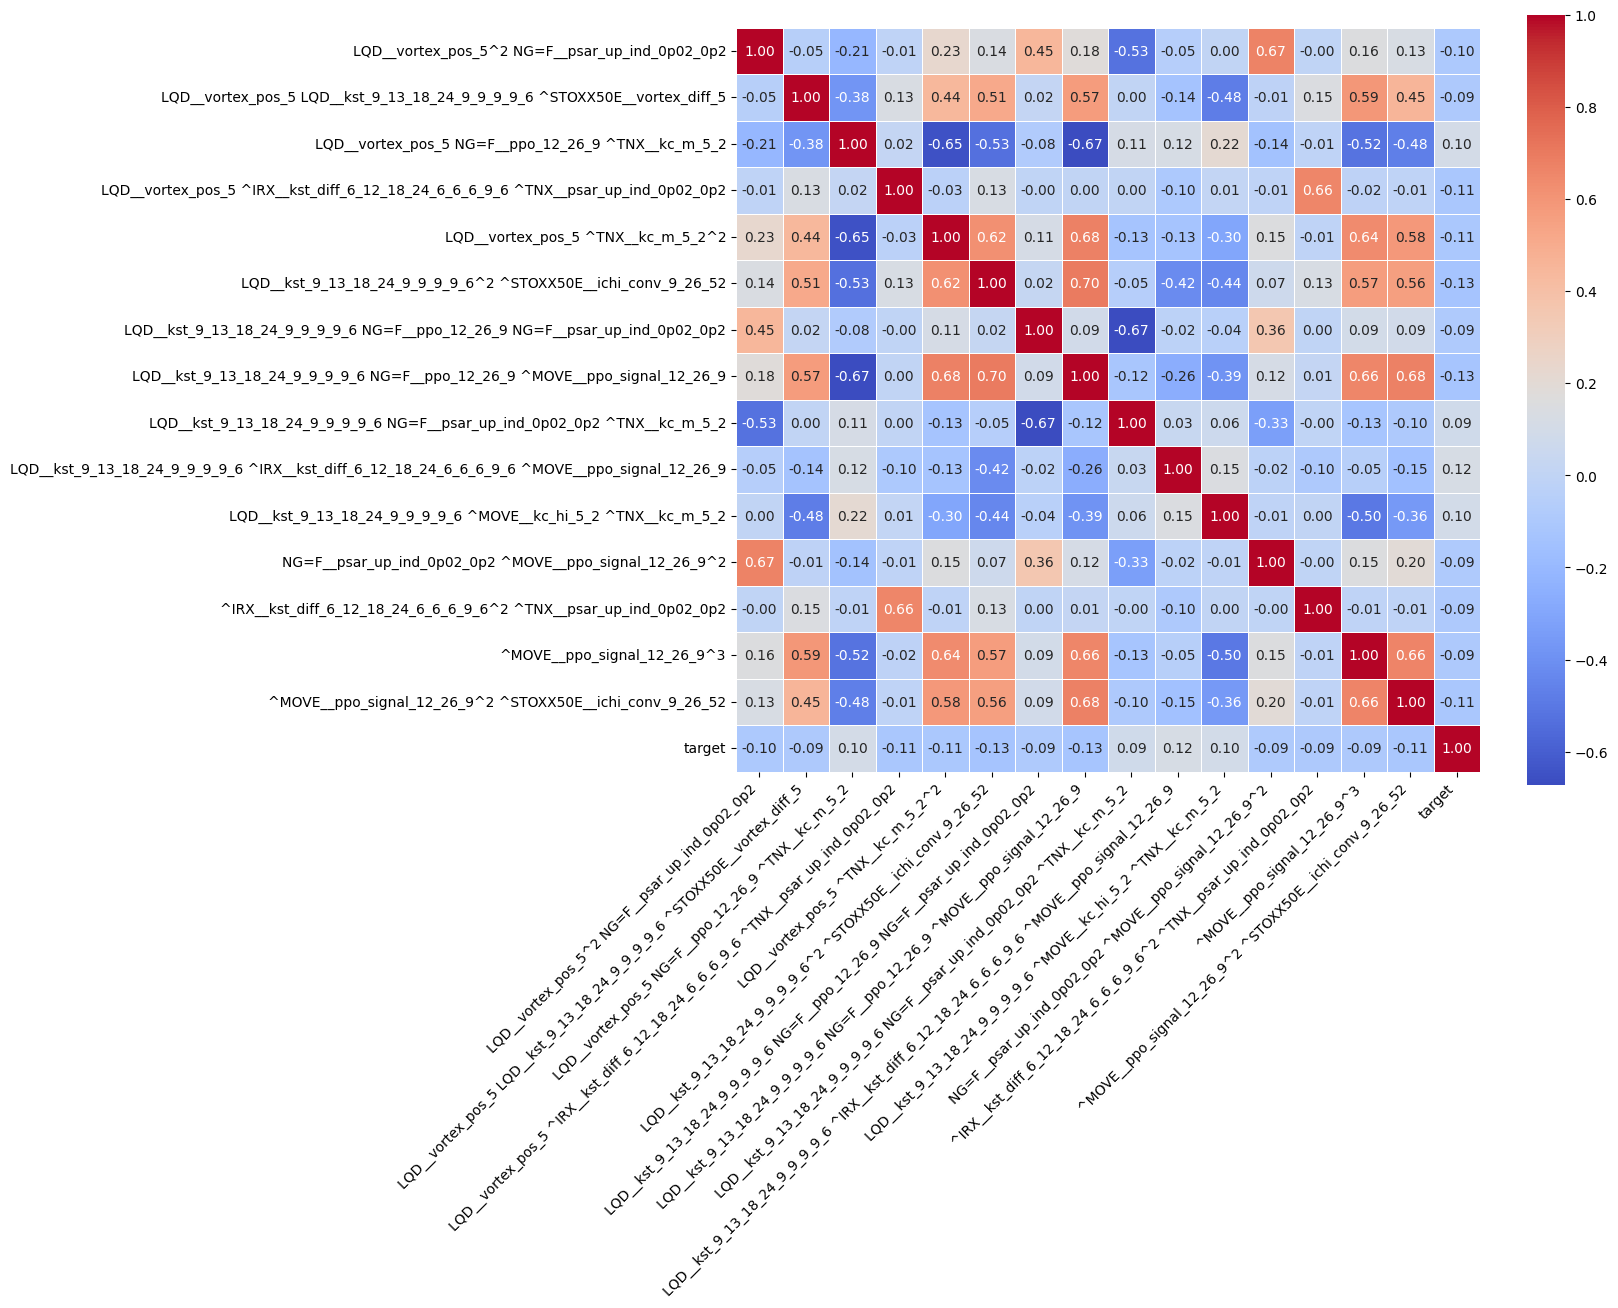

In [123]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.concat([X_train_poly_transformed, y_train], axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [215]:
# 1. Подготовка бинарных таргетов
y_train_bin = (y_train >= 0).astype(int)
y_test_bin = (y_test - 1 >= 0).astype(int)

# 2. Pipeline
pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet", 
        solver="saga", 
        max_iter=10000, 
        random_state=42,
        class_weight="balanced"  # Оставляем для борьбы с дисбалансом
    ))
])

# 3. Сетка параметров
# Добавил C=0.001 для еще более сильной регуляризации
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.1, 0.5, 0.9]
}

f2_scorer = make_scorer(fbeta_score, beta=0.5)
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=f2_scorer, # Чтобы модель училась различать классы, а не подстраиваться под объем
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train_poly_transformed, y_train_bin)
best_model = grid.best_estimator_

# 5. Прогноз вероятностей
y_proba = best_model.predict_proba(X_test_poly_transformed)[:, 1]


# 6. РУЧНОЙ ПОРОГ (Threshold) - беру y_test_bin.mean() чтобы подгонялась доля классов как в тесте
y_pred = (y_proba >= 0.5).astype(int)

# 7. Расчет метрик по новому порогу
f1 = f1_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
accuracy = accuracy_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_proba) # AUC считаем по вероятностям!
tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred).ravel()

In [216]:
print(classification_report(y_test_bin, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.39      0.32       588
           1       0.76      0.64      0.70      1793

    accuracy                           0.58      2381
   macro avg       0.51      0.52      0.51      2381
weighted avg       0.64      0.58      0.60      2381



In [217]:
roc_auc

0.5157191990014076

**Вывод:**

`Текущая модель с настоящей архитектурой и признаковым набором стала справляться чуть лучше - поменял scaler на robust scaler и заменил scoring на f1`

**попробую обучить на признаках до poly**

In [218]:
# 1. Подготовка бинарных таргетов
y_train_bin = (y_train >= 0).astype(int)
y_test_bin = (y_test - 1 >= 0).astype(int)

# 2. Pipeline
pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet", 
        solver="saga", 
        max_iter=10000, 
        random_state=42,
        class_weight="balanced"  # Оставляем для борьбы с дисбалансом
    ))
])

# 3. Сетка параметров
# Добавил C=0.001 для еще более сильной регуляризации
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.1, 0.5, 0.9]
}

f2_scorer = make_scorer(fbeta_score, beta=0.5)
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=f2_scorer, # Чтобы модель училась различать классы, а не подстраиваться под объем
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train_transformed, y_train_bin)
best_model = grid.best_estimator_

# 5. Прогноз вероятностей
y_proba = best_model.predict_proba(X_test_transformed)[:, 1]


# 6. РУЧНОЙ ПОРОГ (Threshold) - беру y_test_bin.mean() чтобы подгонялась доля классов как в тесте
y_pred = (y_proba >= 0.5).astype(int)

# 7. Расчет метрик по новому порогу
f1 = f1_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
accuracy = accuracy_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_proba) # AUC считаем по вероятностям!
tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred).ravel()

In [219]:
print(classification_report(y_test_bin, y_pred))

              precision    recall  f1-score   support

           0       0.15      0.36      0.21       588
           1       0.60      0.32      0.42      1793

    accuracy                           0.33      2381
   macro avg       0.37      0.34      0.31      2381
weighted avg       0.49      0.33      0.37      2381



In [220]:
roc_auc

0.31092001775612643

**Вывод:**

`Качество упало`

## Обоснование метрик

В задаче прогнозирования направления изменения целевой переменной использовалась бинарная классификация, где целевой класс формировался на основе знака будущей доходности. Если значение целевой переменной неотрицательно, наблюдение относилось к положительному классу, в противном случае — к отрицательному. Такой подход позволяет интерпретировать задачу как прогноз торгового сигнала, например роста или отсутствия роста на следующем шаге.

В качестве базовой модели использовалась логистическая регрессия с elastic net регуляризацией. Выбор этой модели обусловлен несколькими причинами. Во-первых, логистическая регрессия является интерпретируемым и устойчивым алгоритмом бинарной классификации, что особенно важно в рамках выпускной квалификационной работы. Во-вторых, elastic net регуляризация объединяет преимущества L1- и L2-регуляризации, позволяя одновременно бороться с переобучением и снижать влияние избыточных либо слабоинформативных признаков. В-третьих, использование `RobustScaler` оправдано особенностями финансовых данных, для которых характерны выбросы и нестабильность распределений.

Для подбора гиперпараметров применялся `GridSearchCV` с временной кросс-валидацией `TimeSeriesSplit`. Использование временного разбиения принципиально важно, поскольку в задачах прогнозирования временных рядов недопустимо случайное перемешивание наблюдений: модель должна обучаться только на прошлом и оцениваться только на будущем. В качестве настраиваемых параметров рассматривались коэффициент регуляризации `C` и параметр `l1_ratio`, определяющий баланс между L1- и L2-компонентами регуляризации. Включение малого значения `C = 0.001` позволяет проверять режим сильной регуляризации, что особенно полезно при риске переобучения на шумных финансовых признаках.

Дополнительно в модели использовался параметр `class_weight = "balanced"`. Это решение обосновано возможным дисбалансом классов, когда число наблюдений одного класса может заметно превышать число наблюдений другого. В таком случае стандартная оптимизация может смещаться в сторону доминирующего класса, тогда как автоматическая балансировка весов повышает чувствительность модели к менее представленному классу.

В качестве основной метрики при подборе гиперпараметров использовалась `F_beta`-мера с параметром `beta = 0.5`. Эта метрика представляет собой гармоническое среднее precision и recall, но в данном случае больший вес придается precision. Такой выбор оправдан для финансовой задачи генерации торговых сигналов, поскольку ложноположительные сигналы, то есть случаи, когда модель рекомендует действие без достаточных оснований, могут приводить к лишним сделкам и росту транзакционных издержек. Следовательно, в контексте торговых решений предпочтительно контролировать качество положительных сигналов и не допускать избыточного числа ошибочных входов. Именно поэтому при настройке модели целесообразно использовать `F_beta` с `beta < 1`, а не обычную accuracy.

После выбора лучшей модели рассчитывались вероятности принадлежности к положительному классу с помощью `predict_proba`. Использование вероятностей, а не только бинарных меток, важно по двум причинам. Во-первых, это позволяет более гибко выбирать порог классификации. Во-вторых, это необходимо для расчета ROC AUC, который оценивает качество ранжирования объектов моделью независимо от конкретного порога принятия решения.

Для перевода вероятностей в итоговый класс использовался фиксированный порог 0.5. Такой вариант является стандартным и интерпретируемым, поскольку положительный класс назначается тогда, когда вероятность его наступления не ниже 50 процентов. После применения порога рассчитывался набор итоговых метрик качества: precision, recall, F1-score, accuracy, ROC AUC, а также матрица ошибок.

Метрика precision показывает долю действительно правильных положительных прогнозов среди всех положительных прогнозов модели. Для рассматриваемой задачи она особенно важна, поскольку отражает надежность торговых сигналов. Чем выше precision, тем меньше доля ложных покупок или ложных входов в позицию.

Метрика recall показывает, какую долю всех реальных положительных случаев модель смогла обнаружить. Эта метрика важна с точки зрения полноты распознавания благоприятных рыночных ситуаций. Однако в торговых задачах стремление к слишком высокому recall может сопровождаться ростом числа ложных сигналов, поэтому recall обычно анализируется совместно с precision.

Метрика F1-score является гармоническим средним precision и recall и используется как компромиссная мера качества бинарной классификации. Она показывает, насколько хорошо модель одновременно поддерживает как точность положительных предсказаний, так и полноту обнаружения положительного класса. В итоговой оценке качества эта метрика удобна как интегральный показатель при фиксированном пороге классификации.

Метрика accuracy показывает долю верно классифицированных наблюдений среди всех наблюдений тестовой выборки. Несмотря на простоту и наглядность, в задачах с возможным дисбалансом классов accuracy не может рассматриваться как основная метрика, поскольку модель может демонстрировать высокое значение accuracy даже при слабом качестве распознавания редкого класса. Поэтому в данной работе accuracy используется только как дополнительный ориентир.

Метрика ROC AUC рассчитывается по вероятностям и характеризует способность модели различать положительный и отрицательный классы на всем диапазоне возможных порогов. Эта метрика особенно полезна тем, что не зависит от одного конкретного значения threshold и позволяет оценить общее качество ранжирования сигналов. В финансовой задаче это важно, поскольку модель может использоваться не только в бинарном режиме, но и как механизм ранжирования потенциальных сделок по степени уверенности.

Матрица ошибок в составе величин `tn`, `fp`, `fn`, `tp` необходима для более детального анализа результатов классификации. Она позволяет явно увидеть количество истинно отрицательных, ложноположительных, ложноотрицательных и истинно положительных прогнозов. Для торговых приложений такой разбор особенно полезен, поскольку ложноположительные и ложноотрицательные ошибки имеют разную экономическую интерпретацию. Ложноположительный прогноз может означать ненужную сделку и дополнительные издержки, а ложноотрицательный — упущенную возможность.
